# 🤖 AI Agents with LangGraph — From Zero to a Working Support Hub



---

**Story Arc — NovaMart**

NovaMart is a fast-growing e-commerce company drowning in customer inquiries. Their small support team handles hundreds of tickets daily — refund questions, shipping lookups, order tracking, and follow-up task scheduling. Today we'll build an AI-powered agent system that can handle all of this autonomously.

We start small (a single LLM call), add tools, wire everything into a graph, and finish with a **live Flask app** — the **NovaMart Support Hub**.

---

**What You'll Learn**

| # | Section | Duration | Key Concept |
|---|---------|----------|-------------|
| 1 | What are AI Agents? | ~10 min | Mental model, agentic loop |
| 2 | LangChain v1 Foundations — LLMs & Tools | ~20 min | `init_chat_model`, Responses API, `@tool` |
| 3 | Prebuilt Agents with `create_agent` | ~25 min | LangChain v1 agent factory, memory |
| 4 | Custom Agents with StateGraph | ~30 min | Nodes, edges, conditional routing |
| 5 | Advanced — Memory, Human-in-Loop, Multi-Agent | ~20 min | Persistent state, approval gates, supervisor |
| 6 | 🚀 Mini-Project: NovaMart Support Hub (Flask) | ~25 min | Full working web demo |

---

**API Note — Responses API**

As of March 2025, OpenAI introduced the **Responses API** (`/v1/responses`) as the recommended replacement for the Chat Completions API. Key benefits:

- **Server-side state**: No more shuttling entire conversation histories back and forth
- **Built-in tools**: Web search, file search, code interpreter — native to the API
- **Better performance**: Reasoning models like GPT-5 perform measurably better on Responses API
- **Future-proof**: All new OpenAI features land on Responses API first

LangChain v1+ and LangGraph v1+ fully support the Responses API. In this notebook, we use it throughout via:
- `init_chat_model("openai:gpt-4o-mini")` — auto-routes to Responses API
- `ChatOpenAI(model="gpt-4o-mini", use_responses_api=True)` — explicit opt-in

The Chat Completions API is **not deprecated** — it's still fully supported for backward compatibility. But for new projects, Responses API is the way forward.


---
## 🔧 Setup — Install & Configure


In [13]:
!pip install -q langchain langchain-openai langgraph python-dotenv flask


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
# !pip install openai python-dotenv pandas
import pandas as pd
import os, json, time
from dotenv import load_dotenv
from openai import OpenAI
import textwrap
import requests

import requests, json, textwrap

# Create a session that ignores proxy env vars (bypasses VPN for local Ollama)
SESSION = requests.Session()
SESSION.trust_env = False  # equivalent of ollama.Client(..., trust_env=False)



import truststore
truststore.inject_into_ssl()



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        

load_dotenv('/Users/shivam13juna/Documents/scaler/iitr_classes/llm_ref/openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

MODEL = 'gpt-5-nano'




client = OpenAI(api_key=api_key)
pretty_print("OpenAI client ready.")

print(f"Using model: {MODEL}")

API key loaded successfully.
OpenAI client ready.
Using model: gpt-5-nano


---
# Section 1 — What Are AI Agents? (~10 min)

Up until now we've used LLMs as **smart autocomplete** — you ask, they answer, conversation over.

An **AI Agent** is different. It's an LLM that can **think, decide, act, observe**, and **loop** until the job is done. Think of the difference between a calculator and a personal assistant:

- **Calculator (plain LLM):** You punch in a question, get an answer.
- **Personal Assistant (agent):** You say *"book me the cheapest flight to Berlin"* — it searches flights, compares prices, checks your calendar, asks for confirmation, and books it.

---

### The Agentic Loop (ReAct Pattern)

```
User Input
    │
    ▼
┌──────────┐
│  REASON  │ ◄─── LLM decides what to do
└────┬─────┘
     │
     ▼
┌──────────┐
│   ACT    │ ◄─── Execute a tool / API call
└────┬─────┘
     │
     ▼
┌──────────┐
│ OBSERVE  │ ◄─── Collect tool output
└────┬─────┘
     │
     ▼
  Need more     ──YES──► back to REASON
  info?
     │
    NO
     ▼
  Final Response
```

The key insight: the LLM **controls the flow**. It decides *which* tool to call, *when* to stop, and *how* to combine results.

---

### Why LangGraph?

Without a framework you end up with spaghetti `if/else` chains, manual retry logic, and no way to visualize what's happening.

**LangGraph** gives you a **graph abstraction**:
- **Nodes** = individual steps (LLM call, tool execution, human approval)
- **Edges** = control flow between steps
- Built-in **state management**, **memory**, **streaming**, and **human-in-the-loop** support

---

### Quick Quiz — Section 1

1. What makes an agent different from a plain LLM?
   - a) Bigger model size
   - b) It can reason, act with tools, and loop ✅
   - c) It only generates text

2. The core agent loop is:
   - a) Encode → Decode
   - b) Reason → Act → Observe → (repeat) → Respond ✅
   - c) Store → Retrieve → Cache


---
# Section 2 — LangChain v1 Foundations: LLMs & Tools (~20 min)

Before we build agents, let's get comfortable with the two building blocks:
1. **Calling an LLM** via the new LangChain v1 API (backed by OpenAI's Responses API)
2. **Defining tools** that agents can use


### 2.1 — Initializing a Model (The New Way)

LangChain v1 introduces `init_chat_model` — a universal model factory. When you pass a model string prefixed with `"openai:"`, it automatically uses the **Responses API** under the hood.


In [ ]:
from langchain.chat_models import init_chat_model

# This uses the Responses API automatically!
llm = init_chat_model(f"openai:{MODEL}", api_key=api_key, temperature=0)

# Simple invocation
response = llm.invoke("Why is Donald Trump so bent on making my portfolio look so red?")
print(response.content)
print()
print(f"Model type: {type(llm).__name__}")

Short answer: it’s not that Trump is literally “making” your portfolio red on purpose. Markets are forward-looking and react to policy expectations, news, and global conditions. Trump’s comments or policy proposals can shift investor expectations, especially for policy-sensitive sectors, and that can cause short- to medium-term market moves. If those moves push your holdings down, your portfolio may turn red.

A bit more detail:
- Policy signals matter. Tariffs, tax changes, deregulation, or trade talks can affect earnings and risk premia, so stocks in affected industries may move a lot.
- Long-term fundamentals still matter. Over time, earnings, balances, and cash flow drive returns more than any single political event.
- Many factors drive markets at once. Fed policy, inflation, global growth, and geopolitical events often dominate short-term moves, with politics simply contributing to the mix.

What you can do (general, non-personalized ideas):
- Don’t try to time politics. Use a pl

**Alternative: Explicit Responses API opt-in**

If you prefer to use `ChatOpenAI` directly (e.g., for more control over parameters), you can explicitly enable the Responses API:


In [ ]:
from langchain_openai import ChatOpenAI

# Explicit Responses API opt-in
llm_explicit = ChatOpenAI(model=MODEL, api_key=api_key, temperature=0, use_responses_api=True)

response = llm_explicit.invoke("Why is Donald Trump so bent on making my portfolio look so red?")
print(response.content)

[{'id': 'rs_06df2abb3ca866880069b4269a63b081948d543ac971f4d912', 'summary': [], 'type': 'reasoning'}, {'type': 'text', 'text': 'Bonjour!\n\nIf you want something more informal: Salut.', 'annotations': [], 'id': 'msg_06df2abb3ca866880069b4269ddb7481948b90c279f968014e'}]


Both approaches hit the Responses API (`/v1/responses`). We'll use `init_chat_model` for prebuilt agents (cleaner syntax) and `ChatOpenAI(use_responses_api=True)` when we need fine-grained control in custom graphs.

### 2.2 — Message Types


In [91]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="You are a friendly NovaMart customer support agent. Keep answers brief."),
    HumanMessage(content="What's your return policy?")
]

response = llm.invoke(messages)
print(response.content)

Here’s our standard policy:

- Window: 30 days from delivery. Some items are final sale and can’t be returned.
- Condition: unused/unopened, in original packaging, with proof of purchase.
- How to start: go to your account > Orders > Return item (or contact us). Refunds go to your original payment method after inspection (usually 5–7 business days).
- Shipping: you generally pay return shipping unless the item arrived damaged, defective, or incorrect.

Want me to check a specific order? If you share your order number, I can confirm eligibility.


In [92]:

messages = [
    SystemMessage(content="You are a friendly NovaMart customer support agent. Keep answers brief."),
    HumanMessage(content="What's your return policy?"),
    AIMessage(content="You can return most items within 30 days with the receipt."),
    HumanMessage(content="What if I opened the package?")
]

response = llm.invoke(messages)
print(response.content)

Opened items are usually returnable within 30 days as long as they’re unused, in their original packaging, and you have the receipt. Some items may have restrictions. If you share the product name or order number, I’ll confirm the exact policy and help start the return.


In [93]:
messages = [
	{"role": "system", "content": "You are a friendly NovaMart customer support agent. Keep answers brief."},
	{"role": "user", "content": "What's your return policy?"},
    {"role": "assistant", "content": "You can return most items within 30 days with the receipt."},
    {"role": "user", "content": "What if I opened the package?"}
]

response = llm.invoke(messages)

print(response.content)

Opened items are usually returnable within 30 days as long as they’re unused and in original packaging. Some categories (like certain electronics or personal care) may have restrictions once opened. Share your order number and item if you want a quick check. You can start a return online or in-store with your receipt.


In [94]:
response

AIMessage(content='Opened items are usually returnable within 30 days as long as they’re unused and in original packaging. Some categories (like certain electronics or personal care) may have restrictions once opened. Share your order number and item if you want a quick check. You can start a return online or in-store with your receipt.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 776, 'prompt_tokens': 59, 'total_tokens': 835, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJIWxNl3iW1tEvjle1eTBwcV0q6V1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cec59-cef5-7b73-947a-992bc9d40adf-0', tool_calls=[], invalid_tool_calls=[], usage_

### 2.3 — The Problem: LLMs Hallucinate Facts

Watch what happens when we ask for something the LLM doesn't actually know:


In [ ]:
# The LLM Might fabricate an answer — it has no access to NovaMart's real data
response = llm.invoke("What is NovaMart order #NM-90210's shipping status?")
print(response.content)
print()
print("👆 This could be an an hallucination, although it is not right now. — the LLM has no access to our order database!")

I don’t have access to NovaMart’s order system, so I can’t look up NM-90210 directly. If you can’t check it yourself, I can help you with alternatives. Here are the quickest options:

Option 1: Check it yourself
- Sign in to your NovaMart account.
- Go to Orders or Order History.
- Search for NM-90210.
- Check the status shown (e.g., Processing, Shipped, In Transit, Out for Delivery, Delivered, Canceled).
- If it’s shipped, click the order to view the tracking number and click the tracking link to see live updates from the carrier.
- If the status isn’t clear or hasn’t updated in a day or two, consider contacting support with your order number.

Option 2: I can help you draft a support message
- If you want, tell me your preferred contact method (email, chat, phone) and any details you want included. I can draft a concise inquiry like:
  Subject: Assistance with shipping status for NM-90210
  Message: Hello NovaMart Support, could you please provide the current shipping status for orde

### 2.4 — The Solution: Tools

A **tool** is a Python function decorated with `@tool`. The LLM can *decide* to call it when it needs real data.


In [31]:
from langchain.tools import tool

# ----- NovaMart Knowledge Base -----
NOVAMART_FAQ = {
    "return policy": "NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.",
    "shipping time": "Standard shipping takes 3-5 business days. Express shipping takes 1-2 business days.",
    "payment methods": "We accept Visa, Mastercard, PayPal, and NovaPay wallet.",
    "warranty": "All electronics come with a 1-year manufacturer warranty. Extended warranty available for $29/year.",
    "contact": "Email: help@novamart.com | Phone: 1-800-NOVA | Live chat available 24/7.",
}

# ----- NovaMart Order Database -----
NOVAMART_ORDERS = {
    "NM-90210": {"status": "shipped", "eta": "March 15", "item": "Wireless Headphones", "carrier": "FedEx"},
    "NM-10042": {"status": "processing", "eta": "March 18", "item": "Smart Watch Pro", "carrier": "TBD"},
    "NM-55331": {"status": "delivered", "eta": "March 10", "item": "USB-C Hub", "carrier": "UPS"},
}

@tool
def faq_lookup(topic: str) -> str:
    """Look up NovaMart FAQ by topic. Available topics: return policy, shipping time, payment methods, warranty, contact."""
    result = NOVAMART_FAQ.get(topic.lower(), None)
    if result:
        return result
    return f"No FAQ entry found for '{topic}'. Available topics: {', '.join(NOVAMART_FAQ.keys())}"

@tool
def order_tracker(order_id: str) -> str:
    """Track a NovaMart order by its ID (e.g., NM-90210)."""
    order = NOVAMART_ORDERS.get(order_id.upper(), None)
    if order:
        return f"Order {order_id}: {order['item']} — Status: {order['status']}, ETA: {order['eta']}, Carrier: {order['carrier']}"
    return f"Order {order_id} not found. Please double-check the order ID."


# Quick test — calling tools directly
print(faq_lookup.invoke({"topic": "return policy"}))
print()
print(order_tracker.invoke({"order_id": "NM-90210"}))

NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

Order NM-90210: Wireless Headphones — Status: shipped, ETA: March 15, Carrier: FedEx


In [27]:
GEOCODE_URL = "https://geocoding-api.open-meteo.com/v1/search"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

WEATHER_CODE_MAP = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snow fall",
    73: "Moderate snow fall",
    75: "Heavy snow fall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail",
}


@tool
def get_weather(location: str) -> str:
    """Get the current weather for a city using Open-Meteo."""
    try:
        # 1) Geocode the location name -> lat/lon
        geo_resp = SESSION.get(
            GEOCODE_URL,
            params={"name": location, "count": 1, "language": "en", "format": "json"},
            timeout=15,
        )
        geo_resp.raise_for_status()
        geo_data = geo_resp.json()

        results = geo_data.get("results")
        if not results:
            return f"Could not find location '{location}'."

        place = results[0]
        name = place.get("name", location)
        country = place.get("country", "")
        admin1 = place.get("admin1", "")
        latitude = place["latitude"]
        longitude = place["longitude"]

        # 2) Fetch current weather
        forecast_resp = SESSION.get(
            FORECAST_URL,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "current": ",".join([
                    "temperature_2m",
                    "relative_humidity_2m",
                    "apparent_temperature",
                    "is_day",
                    "precipitation",
                    "weather_code",
                    "wind_speed_10m",
                    "wind_direction_10m",
                ]),
                "timezone": "auto",
            },
            timeout=15,
        )
        forecast_resp.raise_for_status()
        forecast_data = forecast_resp.json()

        current = forecast_data.get("current")
        if not current:
            return f"Weather data was unavailable for '{location}'."

        weather_code = current.get("weather_code")
        weather_desc = WEATHER_CODE_MAP.get(weather_code, f"Unknown ({weather_code})")

        place_bits = [name]
        if admin1:
            place_bits.append(admin1)
        if country:
            place_bits.append(country)
        place_str = ", ".join(place_bits)

        return (
            f"Current weather for {place_str}:\n"
            f"- Condition: {weather_desc}\n"
            f"- Temperature: {current.get('temperature_2m')}°C\n"
            f"- Feels like: {current.get('apparent_temperature')}°C\n"
            f"- Humidity: {current.get('relative_humidity_2m')}%\n"
            f"- Wind: {current.get('wind_speed_10m')} km/h "
            f"at {current.get('wind_direction_10m')}°\n"
            f"- Precipitation: {current.get('precipitation')} mm\n"
            f"- Daytime: {'Yes' if current.get('is_day') == 1 else 'No'}\n"
            f"- Time: {current.get('time')}"
        )

    except requests.RequestException as e:
        return f"Network/API error while fetching weather for '{location}': {e}"
    except Exception as e:
        return f"Unexpected error while fetching weather for '{location}': {e}"
    

print(get_weather.invoke({"location": "Delhi"}))
print()
print(get_weather.invoke({"location": "Rehovot"}))

Current weather for Delhi, Delhi, India:
- Condition: Overcast
- Temperature: 20.3°C
- Feels like: 21.2°C
- Humidity: 70%
- Wind: 4.6 km/h at 252°
- Precipitation: 0.0 mm
- Daytime: Yes
- Time: 2026-03-14T08:15

Current weather for Rehovot, Central District, Israel:
- Condition: Partly cloudy
- Temperature: 17.2°C
- Feels like: 15.0°C
- Humidity: 60%
- Wind: 14.1 km/h at 94°
- Precipitation: 0.0 mm
- Daytime: No
- Time: 2026-03-14T04:45


### 2.5 — Binding Tools to an LLM

Now the magic: we tell the LLM about these tools. It can then **decide on its own** when to call them.


In [32]:
# Bind tools to the LLM
llm_with_tools = llm.bind_tools([faq_lookup, order_tracker])

# Ask something that requires the order tracker
response = llm_with_tools.invoke("Where is my order NM-90210?")

# The LLM doesn't return text — it returns a TOOL CALL request
print("Content:", response.content)
print()
print("Tool calls:", response.tool_calls)

Content: 

Tool calls: [{'name': 'order_tracker', 'args': {'order_id': 'NM-90210'}, 'id': 'call_5uf2YZnIUcVUMzBDZRNdUL79', 'type': 'tool_call'}]


In [29]:
# Bind tools to the LLM
llm_with_tools = llm.bind_tools([faq_lookup, order_tracker, get_weather])

# Ask something that requires the order tracker
response = llm_with_tools.invoke("What's the temperature in Ahmedabad?")

# The LLM doesn't return text — it returns a TOOL CALL request
print("Content:", response.content)
print()
print("Tool calls:", response.tool_calls)

Content: 

Tool calls: [{'name': 'get_weather', 'args': {'location': 'Ahmedabad'}, 'id': 'call_0XSo9JGaGDvedSPv0z86ZZSQ', 'type': 'tool_call'}]


**Key insight**: The LLM doesn't execute the tool itself — it just *requests* for it to be executed. Something else (the **agent runtime**) needs to actually run the function and feed the result back. That's exactly what LangGraph does.

### Quick Quiz — Section 2

1. Which decorator makes a Python function a tool?
   - a) `@agent`
   - b) `@tool` ✅
   - c) `@function`

2. `init_chat_model("openai:gpt-4o-mini")` uses which API under the hood?
   - a) Chat Completions API
   - b) Responses API ✅
   - c) Assistants API


---
# Section 3 — Prebuilt Agents with `create_agent` (~25 min)

Now we have tools, but someone needs to **orchestrate** the loop:
1. User asks a question
2. LLM decides to call a tool (or answer directly)
3. Tool runs, result comes back
4. LLM incorporates the result and responds

LangChain v1 provides `create_agent` — a production-ready agent factory built on LangGraph. It implements the **ReAct** (Reason + Act) pattern out of the box.


### 3.1 — Our First Agent: NovaMart Support Bot

In [ ]:
from langchain.agents import create_agent

# create_agent accepts model strings — auto-routes to Responses API
support_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker],
    # tools=[faq_lookup, order_tracker, get_weather],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful."
)

print("✅ Agent created! Type:", type(support_agent).__name__)

✅ Agent created! Type: CompiledStateGraph


### 3.2 — Running the Agent

In [ ]:
# Let's ask about an order
result = support_agent.invoke(
    {"messages": [{"role": "user", "content": "Hi! Can you check where my order NM-90210 is?"}]}
)

#result_v2 = support_agent.invoke(
#    {"messages": [HumanMessage(content="Hi! Can you check where my order NM-90210 is?")]}
#)
# Print the full conversation
for msg in result["messages"]:
    role = msg.__class__.__name__
    content = str(msg.content)[:200] if msg.content else "(tool call)"
    print(f"[{role}] {content}")
    print()

[HumanMessage] Hi! Can you check where my order NM-90210 is?

[AIMessage] (tool call)

[ToolMessage] Order NM-90210: Wireless Headphones — Status: shipped, ETA: March 15, Carrier: FedEx

[AIMessage] Great news! Your order NM-90210 has shipped via FedEx, with an estimated arrival (ETA) of March 15.

I don’t see a tracking number in this view. Would you like me to pull the live tracking number and 



In [ ]:
# Now ask an FAQ question
result = support_agent.invoke(
    {"messages": [{"role": "user", "content": "What payment methods do you accept?"}]}
)


# Show final answer
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: We accept Visa, Mastercard, PayPal, and NovaPay wallet. If you’d like, I can help you add or switch your payment method at checkout or check if any region-specific options are available.


In [ ]:
# Ask something that needs NO tool — the agent should answer directly
result = support_agent.invoke(
    {"messages": [{"role": "user", "content": "Thanks for the help! Have a great day!"}]}
)

print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: You're welcome! It was my pleasure to help. If you need anything else—order tracking, returns, or product info—I'm here for you. Have a wonderful day!


In [ ]:
# Ask something that needs NO tool — the agent should answer directly
result = support_agent.invoke(
    {"messages": [{"role": "user", "content": "By the way, I also need temperature for Ahmedabad."}]}
)

print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Ahmedabad current temperature: 22.2°C (feels like 23.5°C). Mainly clear. Time: 2026-03-14 08:30. Want me to check more details or set a weather alert?


### 3.3 — Watching the Agent Think (Streaming)

Let's stream the agent's reasoning step by step to see the Reason → Act → Observe loop in action:


In [42]:
# Stream events to see the agent's internal reasoning
for event in support_agent.stream(
    {"messages": [{"role": "user", "content": "Tell me status of order NM-55331. I need to return order NM-55331. What's the return policy?"}]},
    stream_mode="updates"
):
    for node_name, node_output in event.items():
        print(f"--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                role = msg.__class__.__name__
                content = str(msg.content) if msg.content else "(tool call request)"
                # If this is an AI message and it requested tool calls
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    print("    Tool calls:")
                    for tc in msg.tool_calls:
                        print(f"      - tool name: {tc.get('name')}")
                        print(f"        args: {tc.get('args')}")
                        print(f"        id: {tc.get('id')}")
                print(f"  [{role}] {content}")
        print()

--- model ---
    Tool calls:
      - tool name: order_tracker
        args: {'order_id': 'NM-55331'}
        id: call_cJyi4c6CRhSWHjAVWU7PfWz0
      - tool name: faq_lookup
        args: {'topic': 'return policy'}
        id: call_HDpREcNbsTXJMihgZrUdOkBa
  [AIMessage] (tool call request)

--- tools ---
  [ToolMessage] Order NM-55331: USB-C Hub — Status: delivered, ETA: March 10, Carrier: UPS

--- tools ---
  [ToolMessage] NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

--- model ---
  [AIMessage] Here’s what I found:

- Order NM-55331: USB-C Hub — Status: Delivered on March 10 via UPS.

Return policy:
- 30-day no-questions-asked return for all items in original packaging.

How to return:
- You can start a return within 30 days of delivery and ensure the item is in its original packaging.

Would you like me to initiate the return for NM-55331 or guide you to the returns portal?



Notice how the agent:
1. First calls `order_tracker` to check what the order is
2. Then calls `faq_lookup` to get the return policy
3. Finally combines both results into a helpful answer

This is the **ReAct loop** in action — the LLM decided on its own to make two tool calls.

### 3.4 — Adding Memory (Conversation Persistence)

Right now, each `invoke` call is stateless. The agent forgets everything between calls. Let's fix that with a **checkpointer**.


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

# Create agent WITH memory
memory = InMemorySaver()
support_agent_with_memory = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful.",
    checkpointer=memory
)

# Thread config — think of this as a "conversation ID"
config = {"configurable": {"thread_id": "customer-session-001"}}

# First message
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "Hi! I'm Alice. Can you check order NM-10042?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Hi Alice! Here’s the latest on NM-10042:

- Item: Smart Watch Pro
- Status: Processing
- ETA: March 18
- Carrier: TBD

The carrier will be assigned once it ships. I can set up alerts to notify you when it ships or if there are any changes—would you like me to enable those? If you need changes to the order (cancellation or updates), just let me know.


In [ ]:
# Second message — same thread, agent should remember Alice
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "What about NM-90210?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Hi Alice! Here are the details for NM-90210:

- Item: Wireless Headphones
- Status: Shipped
- ETA: March 15
- Carrier: FedEx

Would you like me to pull the tracking number (if available) or set up shipment alerts for updates? I can also help with delivery instructions or changes if needed.


In [ ]:
# Third message — the agent should remember BOTH orders
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "Can you summarize both orders for me?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Here’s a quick summary of both orders:

- NM-10042 — Smart Watch Pro
  - Status: Processing
  - ETA: March 18
  - Carrier: TBD
  - Notes: Carrier will be assigned once it ships. I can set up alerts for shipping updates if you’d like.

- NM-90210 — Wireless Headphones
  - Status: Shipped
  - ETA: March 15
  - Carrier: FedEx
  - Notes: I can fetch the tracking number if available and enable shipment alerts, or add delivery instructions if needed.

Would you like me to enable alerts for both orders or look up the tracking number for NM-90210?


**Key takeaway**: `InMemorySaver` + `thread_id` gives each customer their own persistent conversation. The agent remembers everything said within that thread.

### Quick Quiz — Section 3

1. `create_agent` is from which package?
   - a) `langgraph.prebuilt`
   - b) `langchain.agents` ✅
   - c) `openai`

2. What does `InMemorySaver` provide?
   - a) Saves LLM weights
   - b) Persists conversation state across calls ✅
   - c) Compresses messages


---
# Section 4 — Custom Agents with StateGraph (~30 min)

### Why `create_agent` Isn't Always Enough

`create_agent` is powerful — but it's a **black box**. The LLM decides everything: which tool to call, when to stop, how to route. For a quick FAQ bot, that's fine.

But imagine NovaMart's real support workflow:

**Scenario:** A customer writes *"My laptop arrived broken. Order NM-90210. I want a refund and someone to call me back."*

This single message needs **four things** to happen:

1. **Classify the intent** — is this a complaint? A refund request? An order inquiry? All three?
2. **Look up the order** — mandatory step before any refund can be processed
3. **Route to the right handler** — complaints go to escalation, refunds require approval, order lookups are self-serve
4. **Create a follow-up task** — the callback request must be logged regardless of what else happens

With `create_agent`, the LLM *might* do all four things... or it might skip the task creation, or forget to look up the order, or try to process the refund without checking the order status first. You're hoping the LLM figures out the right sequence every time.

**With StateGraph, you *guarantee* it:**
```
User Message
     │
     ▼
┌──────────┐
│ CLASSIFY  │ ─── always runs first
└────┬──────┘
     │
     ▼
┌──────────────────┐
│ ROUTE BY INTENT  │ ─── deterministic branching
└──┬────┬────┬─────┘
   │    │    │
   ▼    ▼    ▼
  FAQ  ORDER  COMPLAINT  ─── specialized handlers
         │
         ▼
   ┌───────────┐
   │ LOG TASK  │ ─── always runs if callback requested
   └───────────┘
```

The difference:
- **`create_agent`** = LLM decides the flow (flexible but unpredictable)
- **`StateGraph`** = You design the flow, LLM handles the reasoning *within* each step (deterministic and auditable)

In production, this matters. Your support manager wants to know: *"Did every complaint get classified? Did every refund request check the order first?"* With a graph, you can answer yes with certainty.

---

### 4.1 — Building Blocks

| Concept | What it is | NovaMart example |
|---------|------------|-----------------|
| **State** | A `TypedDict` holding all data flowing through the graph | Messages + detected intent + order info |
| **Node** | A function that reads state, does work, returns updates | `classify_intent`, `handle_complaint` |
| **Edge** | A fixed connection between nodes | classify → route |
| **Conditional Edge** | A branch — different paths based on state | if complaint → escalate; if FAQ → answer |


### 4.2 — Baby Steps: A Simple Graph (No LLM)

Before involving LLMs, let's build the simplest possible graph to understand the mechanics:


In [46]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Step 1: Define state
class SimpleState(TypedDict):
    message: str
    steps: list

# Step 2: Define nodes (just Python functions)
def greet(state: SimpleState):
    return {
        "message": "Hello from NovaMart!",
        "steps": state.get("steps", []) + ["greet"]
    }

def classify(state: SimpleState):
    return {
        "message": state["message"] + " How can we help you today?",
        "steps": state["steps"] + ["classify"]
    }

# Step 3: Build the graph
builder = StateGraph(SimpleState)
builder.add_node("greet", greet)
builder.add_node("classify", classify)

# Step 4: Wire edges
builder.add_edge(START, "greet")
builder.add_edge("greet", "classify")
builder.add_edge("classify", END)

# Step 5: Compile and run
simple_graph = builder.compile()

result = simple_graph.invoke({"message": "", "steps": []})
print("Final state:", result)

Final state: {'message': 'Hello from NovaMart! How can we help you today?', 'steps': ['greet', 'classify']}


### 4.3 — Visualizing the Graph

LangGraph can render your graph as an image:


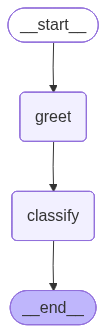

In [47]:
from IPython.display import Image, display

try:
    display(Image(simple_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(simple_graph.get_graph().draw_mermaid())

### 4.4 — Adding Conditional Routing

Now let's add decision logic. We'll use our Responses API-enabled LLM to classify intent, then route to different handler nodes:


In [58]:
from typing import Literal, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI

# LLM with Responses API for custom graph usage
llm = ChatOpenAI(model=MODEL, temperature=0, use_responses_api=True, api_key=api_key)

class SupportState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: str

# ----- Node: Classify intent using LLM -----
def classify_intent(state: SupportState):
    last_msg = state["messages"][-1].content if state["messages"] else ""

    classification_prompt = [
        SystemMessage(content="""Classify the customer message into exactly one category.
Reply with ONLY the category name, nothing else.
Categories: faq, order_tracking, complaint, general"""),
        HumanMessage(content=last_msg)
    ]

    result = llm.invoke(classification_prompt)
    intent = result.text.strip().lower()

    # Normalize
    if "faq" in intent:
        intent = "faq"
    elif "order" in intent or "track" in intent:
        intent = "order_tracking"
    elif "complaint" in intent:
        intent = "complaint"
    else:
        intent = "general"

    return {"intent": intent}

# ----- Node: Handle FAQ -----
def handle_faq(state: SupportState):
    last_msg = state["messages"][-1].content
    llm_with_faq = llm.bind_tools([faq_lookup])
    response = llm_with_faq.invoke([
        SystemMessage(content="Answer the customer's FAQ question using the faq_lookup tool. Be helpful and concise."),
        HumanMessage(content=last_msg)
    ])

    if response.tool_calls:
        tool_result = faq_lookup.invoke(response.tool_calls[0]["args"])
        final = llm.invoke([
            SystemMessage(content="Rewrite this FAQ answer in a friendly customer-support tone:"),
            HumanMessage(content=tool_result)
        ])
        return {"messages": [AIMessage(content=final.content)]}

    return {"messages": [response]}

# ----- Node: Handle Order Tracking -----
def handle_order(state: SupportState):
    last_msg = state["messages"][-1].content
    llm_with_tracker = llm.bind_tools([order_tracker])
    response = llm_with_tracker.invoke([
        SystemMessage(content="Track the customer's order using the order_tracker tool. Extract the order ID from their message."),
        HumanMessage(content=last_msg)
    ])

    if response.tool_calls:
        tool_result = order_tracker.invoke(response.tool_calls[0]["args"])
        final = llm.invoke([
            SystemMessage(content="Present this order tracking info in a friendly way:"),
            HumanMessage(content=tool_result)
        ])
        return {"messages": [AIMessage(content=final.content)]}

    return {"messages": [response]}

# ----- Node: Handle Complaint -----
def handle_complaint(state: SupportState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="You are NovaMart support. The customer has a complaint. Acknowledge their frustration, apologize sincerely, and offer to escalate. Be empathetic."),
        HumanMessage(content=last_msg)
    ])
    return {"messages": [response]}

# ----- Node: Handle General -----
def handle_general(state: SupportState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="You are NovaMart's friendly support agent. Answer the customer's general question helpfully."),
        HumanMessage(content=last_msg)
    ])
    return {"messages": [response]}

# ----- Router function -----
def route_by_intent(state: SupportState) -> Literal["handle_faq", "handle_order", "handle_complaint", "handle_general"]:
    intent = state.get("intent", "general")
    mapping = {
        "faq": "handle_faq",
        "order_tracking": "handle_order",
        "complaint": "handle_complaint",
        "general": "handle_general"
    }
    return mapping.get(intent, "handle_general")

# ----- Build the graph -----
builder = StateGraph(SupportState)

builder.add_node("classify", classify_intent)
builder.add_node("handle_faq", handle_faq)
builder.add_node("handle_order", handle_order)
builder.add_node("handle_complaint", handle_complaint)
builder.add_node("handle_general", handle_general)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_by_intent)
builder.add_edge("handle_faq", END)
builder.add_edge("handle_order", END)
builder.add_edge("handle_complaint", END)
builder.add_edge("handle_general", END)

custom_agent = builder.compile()

print("✅ Custom NovaMart support graph built!")

✅ Custom NovaMart support graph built!


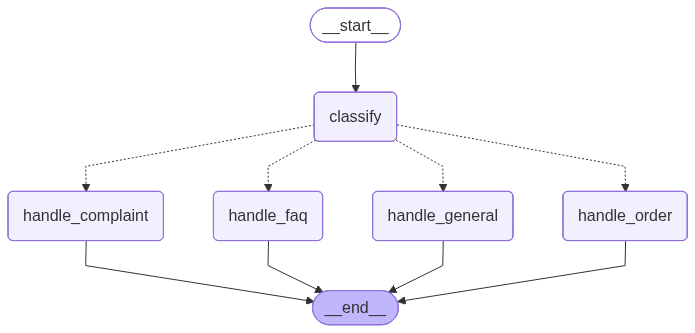

In [59]:
# Visualize our custom graph
try:
    display(Image(custom_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(custom_agent.get_graph().draw_mermaid())

### 4.5 — Testing Every Path

In [73]:
# Test FAQ path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="What's your return policy?")],
    "intent": ""
})
print("📋 FAQ Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

📋 FAQ Test
Intent: faq
🤖 Agent: Absolutely! At NovaMart, your satisfaction matters. You can return any item within 30 days—no questions asked—as long as it’s in its original packaging. If you’d like help starting a return, our team is here to assist.



In [67]:
result

{'messages': [HumanMessage(content="What's your return policy?", additional_kwargs={}, response_metadata={}, id='37c77fd7-b649-4d94-b84f-2e6e3cac3bfe'),
  AIMessage(content=[{'id': 'rs_0ffd6cbaa85b7e000069b4ea5dfbe8819b9a0a7a9151931b4d', 'summary': [], 'type': 'reasoning'}, {'type': 'text', 'text': 'At NovaMart, we want you to shop with confidence. That’s why we offer a 30-day, no-questions-asked return on all items, as long as they’re in their original packaging. If you need to return something, just start the return within 30 days of delivery and we’ll take care of the rest.', 'annotations': [], 'id': 'msg_0ffd6cbaa85b7e000069b4ea6568bc819bbc1158e76cf2161c'}], additional_kwargs={}, response_metadata={}, id='14bc7710-ceb8-49f0-b231-6ac7def05942', tool_calls=[], invalid_tool_calls=[])],
 'intent': 'faq'}

In [72]:
result['messages'][-1].text

'At NovaMart, we want you to shop with confidence. That’s why we offer a 30-day, no-questions-asked return on all items, as long as they’re in their original packaging. If you need to return something, just start the return within 30 days of delivery and we’ll take care of the rest.'

In [74]:
# Test Order Tracking path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="Where is my order NM-90210?")],
    "intent": ""
})
print("📦 Order Tracking Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

📦 Order Tracking Test
Intent: order_tracking
🤖 Agent: Here’s your order update in a friendly snapshot:

- Order number: NM-90210
- Item: Wireless Headphones
- Status: Shipped
- Carrier: FedEx
- Estimated delivery: March 15

Would you like me to fetch the tracking number or set up delivery alerts for you?



In [75]:
# Test Complaint path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="I'm really frustrated — my package arrived damaged and nobody is helping me!")],
    "intent": ""
})
print("😤 Complaint Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

😤 Complaint Test
Intent: complaint
🤖 Agent: I’m really sorry you’re dealing with this. I can hear how frustrating it is, and I want to get this fixed for you as quickly as possible. I can escalate this to our claims team right away and set you up with a replacement or a refund—your choice.

To speed things up, could you please share:
- Your order number
- Photos of the damaged item and the packaging (if you have them)
- Do you prefer a replacement or a full refund?
- Any other details you have (delivery date, carrier, etc.)

In the meantime, please keep the damaged item and all packaging materials. This helps with the claim, and our team may request it.

If you’d like, I can start the escalation now and mark this as urgent. Just send me the details above, and tell me whether you want a replacement or a refund. I can also connect you with a supervisor if you prefer to speak with someone directly.



In [76]:
# Test General path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="Hey, do you guys have a physical store in New York?")],
    "intent": ""
})
print("💬 General Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)

💬 General Test
Intent: faq
🤖 Agent: Need help? We’re here for you around the clock. Choose the option that’s easiest for you:

- Email: help@novamart.com
- Phone: 1-800-NOVA
- Live chat: available 24/7 on our website


### Quick Quiz — Section 4

1. Which class defines custom agent state in LangGraph?
   - a) `AgentDict`
   - b) `TypedDict` ✅
   - c) `StateGraph`

2. What does `add_conditional_edges` do?
   - a) Adds a fixed transition
   - b) Routes to different nodes based on a condition function ✅
   - c) Creates parallel execution

3. A LangGraph node is:
   - a) A JSON schema
   - b) A Python function that takes state and returns state updates ✅
   - c) A database table


---
# Section 5 — Advanced: Memory, Human-in-the-Loop, Multi-Agent (~20 min)

Now that we can build custom agents, let's explore three powerful patterns.

### 5.1 — Persistent Memory with Custom Graph


In [80]:
# Add memory to our custom graph
memory = InMemorySaver()

custom_agent_with_memory = builder.compile(checkpointer=memory)

config = {"configurable": {"thread_id": "session-alice-42"}}

# Turn 1
result = custom_agent_with_memory.invoke(
    {"messages": [HumanMessage(content="Hi! What payment methods do you accept?")]},
    config=config
)
print("Turn 1 🤖:", result["messages"][-1].text)
print()

# Turn 2 — same session
result = custom_agent_with_memory.invoke(
    {"messages": [HumanMessage(content="And what about shipping times?")], "intent": ""},
    config=config
)
print("Turn 2 🤖:", result["messages"][-1].text)
print()

print(f"Total messages in state: {len(result['messages'])}")

Turn 1 🤖: We accept Visa, Mastercard, PayPal, and NovaPay Wallet. If you have any questions or need help with a payment, we’re here for you—just let us know!

Turn 2 🤖: Absolutely! Standard shipping typically arrives in 3–5 business days, while Express shipping delivers in 1–2 business days. If you’d like help choosing the best option for you, I’m happy to assist.

Total messages in state: 4


### 5.2 — Human-in-the-Loop (Approval Gate)

For sensitive actions (refund processing, account deletion), you often want a human to approve before the agent acts.


In [ ]:
class EscalationState(TypedDict):
    messages: Annotated[list, add_messages]
    complaint: str
    approved: bool

def intake_complaint(state: EscalationState):
    msg = state["messages"][-1].content
    return {"complaint": msg, "approved": False}

def human_review(state: EscalationState):
    """
    In production, this would pause via LangGraph's interrupt_before / interrupt_after.
    For demo, we simulate auto-approval.
    """
    print(f"\n🧑‍💼 HUMAN REVIEWER sees complaint: '{state['complaint'][:80]}...'")
    print("🧑‍💼 Decision: APPROVED for escalation")
    return {"approved": True}

def escalate(state: EscalationState):
    response = llm.invoke([
        SystemMessage(content="A complaint has been approved for escalation. Draft a priority ticket response acknowledging the issue and assigning a senior agent."),
        HumanMessage(content=state["complaint"])
    ])
    return {"messages": [response]}

def reject(state: EscalationState):
    return {"messages": [AIMessage(content="This complaint will be handled through standard support channels. A representative will follow up within 24 hours.")]}

def check_approval(state: EscalationState) -> Literal["escalate", "reject"]:
    return "escalate" if state["approved"] else "reject"

# Build
esc_builder = StateGraph(EscalationState)
esc_builder.add_node("intake", intake_complaint)
esc_builder.add_node("review", human_review)
esc_builder.add_node("escalate", escalate)
esc_builder.add_node("reject", reject)

esc_builder.add_edge(START, "intake")
esc_builder.add_edge("intake", "review")
esc_builder.add_conditional_edges("review", check_approval)
esc_builder.add_edge("escalate", END)
esc_builder.add_edge("reject", END)

escalation_graph = esc_builder.compile()

# Test it
result = escalation_graph.invoke({
    "messages": [HumanMessage(content="My expensive laptop arrived completely shattered. This is the third time NovaMart has ruined my order. I want a full refund AND compensation.")],
    "complaint": "",
    "approved": False
})

print("\n🤖 Final response:", result["messages"][-1].text)

In [ ]:
# Visualize escalation graph
try:
    display(Image(escalation_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(escalation_graph.get_graph().draw_mermaid())

### 5.3 — Multi-Agent Architecture (Supervisor Pattern)

In complex systems, a **supervisor agent** routes requests to **specialized sub-agents**:

```
                    ┌───────────┐
     User ────►    │ SUPERVISOR │
                    └─────┬─────┘
                          │
              ┌───────────┼───────────┐
              ▼           ▼           ▼
         ┌────────┐ ┌─────────┐ ┌─────────┐
         │  FAQ   │ │  ORDER  │ │  TASK   │
         │ Agent  │ │  Agent  │ │ Planner │
         └────────┘ └─────────┘ └─────────┘
```


In [ ]:
# Task management tool — new capability!
TASK_STORE = []

@tool
def create_task(description: str, priority: str = "medium") -> str:
    """Create a follow-up task for the support team. Priority can be: low, medium, high."""
    task = {"id": len(TASK_STORE) + 1, "description": description, "priority": priority, "status": "open"}
    TASK_STORE.append(task)
    return f"✅ Task #{task['id']} created: '{description}' [Priority: {priority}]"

@tool
def list_tasks() -> str:
    """List all open support tasks."""
    if not TASK_STORE:
        return "No open tasks."
    lines = [f"  #{t['id']} [{t['priority'].upper()}] {t['description']} — {t['status']}" for t in TASK_STORE]
    return "Open Tasks:\n" + "\n".join(lines)

# Create specialized sub-agents using create_agent (Responses API)
faq_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup],
    system_prompt="You are NovaMart's FAQ specialist. Answer questions using the FAQ knowledge base."
)

order_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[order_tracker],
    system_prompt="You are NovaMart's order tracking specialist. Help customers track their orders."
)

task_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[create_task, list_tasks],
    system_prompt="You are NovaMart's task planner. Create follow-up tasks when asked."
)

print("✅ Three specialized sub-agents created!")

In [ ]:
class SupervisorState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str

def supervisor_router(state: SupervisorState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="""You are a routing supervisor. Based on the customer message, decide which specialist to route to.
Reply with ONLY one word: faq, order, or task

- faq: questions about policies, payment, shipping info, warranty
- order: questions about specific order status or tracking
- task: requests to create follow-ups, schedule callbacks, plan actions"""),
        HumanMessage(content=last_msg)
    ])
    route = response.content.strip().lower()
    if "order" in route:
        route = "order"
    elif "task" in route:
        route = "task"
    else:
        route = "faq"
    return {"route": route}

def faq_handler(state: SupervisorState):
    result = faq_agent.invoke({"messages": state["messages"]})
    return {"messages": [result["messages"][-1]]}

def order_handler(state: SupervisorState):
    result = order_agent.invoke({"messages": state["messages"]})
    return {"messages": [result["messages"][-1]]}

def task_handler(state: SupervisorState):
    result = task_agent.invoke({"messages": state["messages"]})
    return {"messages": [result["messages"][-1]]}

def route_decision(state: SupervisorState) -> Literal["faq_handler", "order_handler", "task_handler"]:
    return {"faq": "faq_handler", "order": "order_handler", "task": "task_handler"}.get(state["route"], "faq_handler")

# Build supervisor graph
sup_builder = StateGraph(SupervisorState)
sup_builder.add_node("supervisor", supervisor_router)
sup_builder.add_node("faq_handler", faq_handler)
sup_builder.add_node("order_handler", order_handler)
sup_builder.add_node("task_handler", task_handler)

sup_builder.add_edge(START, "supervisor")
sup_builder.add_conditional_edges("supervisor", route_decision)
sup_builder.add_edge("faq_handler", END)
sup_builder.add_edge("order_handler", END)
sup_builder.add_edge("task_handler", END)

supervisor_graph = sup_builder.compile()
print("✅ Supervisor multi-agent system built!")

In [ ]:
# Test all three routes
print("=" * 60)
print("TEST 1: FAQ Route")
print("=" * 60)
result = supervisor_graph.invoke({
    "messages": [HumanMessage(content="What's your warranty policy?")],
    "route": ""
})
print("Route:", result["route"])
print("🤖:", result["messages"][-1].text)
print()

print("=" * 60)
print("TEST 2: Order Route")
print("=" * 60)
result = supervisor_graph.invoke({
    "messages": [HumanMessage(content="Track my order NM-55331")],
    "route": ""
})
print("Route:", result["route"])
print("🤖:", result["messages"][-1].text)
print()

print("=" * 60)
print("TEST 3: Task Route")
print("=" * 60)
result = supervisor_graph.invoke({
    "messages": [HumanMessage(content="Please create a follow-up task to call me back about my refund request. High priority.")],
    "route": ""
})
print("Route:", result["route"])
print("🤖:", result["messages"][-1].text)
print()

# Show all tasks
print("📋 All Tasks:", list_tasks.invoke({}))

In [ ]:
# Visualize the supervisor graph
try:
    display(Image(supervisor_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(supervisor_graph.get_graph().draw_mermaid())

### Quick Quiz — Section 5

1. Human-in-the-loop is used for:
   - a) Reducing latency
   - b) Adding approval before sensitive actions ✅
   - c) Optimizing embeddings

2. In a multi-agent system, the supervisor:
   - a) Runs all agents in parallel
   - b) Routes requests to specialized agents ✅
   - c) Only handles one query type

3. Persistent memory helps with:
   - a) Faster tokenization
   - b) Keeping context across multiple conversation turns ✅
   - c) Smaller model size


---
# Section 6 — 🚀 Mini-Project: NovaMart Support Hub (Flask App) (~25 min)

Let's bring everything together into a real, runnable web application.

**Architecture:**
```
Browser  ──HTTP POST──►  Flask App  ──invoke──►  Supervisor Graph
                                                        │
                                              ┌─────────┼──────────┐
                                              ▼         ▼          ▼
                                          FAQ Agent  Order Agent  Task Agent
```

All agents use the **Responses API** via `create_agent("openai:gpt-4o-mini", ...)`.


### 6.1 — The Flask App

In [ ]:
%%writefile novamart_app.py
"""
NovaMart Support Hub — Flask Demo App
Uses LangChain v1 + LangGraph v1 + OpenAI Responses API

Run: python novamart_app.py
Visit: http://localhost:5050
"""

import os
from dotenv import load_dotenv
load_dotenv()

from typing import TypedDict, Literal, Annotated
from flask import Flask, render_template_string, request, jsonify

from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

# ================================================================
# CONFIG
# ================================================================
MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

# LLM for custom graph nodes (explicit Responses API)
llm = ChatOpenAI(model=MODEL, temperature=0, use_responses_api=True)

# ================================================================
# DATA STORES
# ================================================================
NOVAMART_FAQ = {
    "return policy": "NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.",
    "shipping time": "Standard shipping takes 3-5 business days. Express shipping takes 1-2 business days.",
    "payment methods": "We accept Visa, Mastercard, PayPal, and NovaPay wallet.",
    "warranty": "All electronics come with a 1-year manufacturer warranty. Extended warranty available for $29/year.",
    "contact": "Email: help@novamart.com | Phone: 1-800-NOVA | Live chat available 24/7.",
}

NOVAMART_ORDERS = {
    "NM-90210": {"status": "shipped", "eta": "March 15", "item": "Wireless Headphones", "carrier": "FedEx"},
    "NM-10042": {"status": "processing", "eta": "March 18", "item": "Smart Watch Pro", "carrier": "TBD"},
    "NM-55331": {"status": "delivered", "eta": "March 10", "item": "USB-C Hub", "carrier": "UPS"},
}

TASK_STORE = []

# ================================================================
# TOOLS
# ================================================================
@tool
def faq_lookup(topic: str) -> str:
    """Look up NovaMart FAQ by topic. Topics: return policy, shipping time, payment methods, warranty, contact."""
    result = NOVAMART_FAQ.get(topic.lower(), None)
    if result:
        return result
    return f"No FAQ entry for '{topic}'. Available: {', '.join(NOVAMART_FAQ.keys())}"

@tool
def order_tracker(order_id: str) -> str:
    """Track a NovaMart order by ID (e.g., NM-90210)."""
    order = NOVAMART_ORDERS.get(order_id.upper(), None)
    if order:
        return f"Order {order_id}: {order['item']} — Status: {order['status']}, ETA: {order['eta']}, Carrier: {order['carrier']}"
    return f"Order {order_id} not found."

@tool
def create_task(description: str, priority: str = "medium") -> str:
    """Create a follow-up task. Priority: low, medium, high."""
    task = {"id": len(TASK_STORE) + 1, "description": description, "priority": priority, "status": "open"}
    TASK_STORE.append(task)
    return f"Task #{task['id']} created: '{description}' [Priority: {priority}]"

@tool
def list_tasks() -> str:
    """List all open support tasks."""
    if not TASK_STORE:
        return "No open tasks."
    lines = [f"  #{t['id']} [{t['priority'].upper()}] {t['description']}" for t in TASK_STORE]
    return "Open Tasks:\n" + "\n".join(lines)

# ================================================================
# SUB-AGENTS (all using Responses API via model string)
# ================================================================
faq_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup],
    system_prompt="You are NovaMart's FAQ specialist. Answer using the FAQ tool. Be concise."
)
order_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[order_tracker],
    system_prompt="You are NovaMart's order tracking specialist. Track orders using the tool."
)
task_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[create_task, list_tasks],
    system_prompt="You are NovaMart's task planner. Create or list tasks as requested."
)

# ================================================================
# SUPERVISOR GRAPH
# ================================================================
class SupervisorState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str

def supervisor_router(state: SupervisorState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="""Classify the customer message. Reply with ONLY one word: faq, order, or task
- faq: policy/payment/shipping/warranty/general questions
- order: specific order tracking (has order ID or asks about order status)
- task: create follow-ups, schedule callbacks, plan actions"""),
        HumanMessage(content=last_msg)
    ])
    route = response.content.strip().lower()
    if "order" in route:
        route = "order"
    elif "task" in route:
        route = "task"
    else:
        route = "faq"
    return {"route": route}

def faq_handler(state: SupervisorState):
    result = faq_agent.invoke({"messages": state["messages"]})
    return {"messages": [result["messages"][-1]]}

def order_handler(state: SupervisorState):
    result = order_agent.invoke({"messages": state["messages"]})
    return {"messages": [result["messages"][-1]]}

def task_handler(state: SupervisorState):
    result = task_agent.invoke({"messages": state["messages"]})
    return {"messages": [result["messages"][-1]]}

def route_decision(state: SupervisorState) -> Literal["faq_handler", "order_handler", "task_handler"]:
    return {"faq": "faq_handler", "order": "order_handler", "task": "task_handler"}.get(state["route"], "faq_handler")

sup_builder = StateGraph(SupervisorState)
sup_builder.add_node("supervisor", supervisor_router)
sup_builder.add_node("faq_handler", faq_handler)
sup_builder.add_node("order_handler", order_handler)
sup_builder.add_node("task_handler", task_handler)
sup_builder.add_edge(START, "supervisor")
sup_builder.add_conditional_edges("supervisor", route_decision)
sup_builder.add_edge("faq_handler", END)
sup_builder.add_edge("order_handler", END)
sup_builder.add_edge("task_handler", END)

memory = InMemorySaver()
supervisor = sup_builder.compile(checkpointer=memory)

# ================================================================
# FLASK APP
# ================================================================
app = Flask(__name__)

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>NovaMart Support Hub</title>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; background: #0f172a; color: #e2e8f0; height: 100vh; display: flex; flex-direction: column; }
        .header { background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%); padding: 16px 24px; border-bottom: 1px solid #334155; display: flex; align-items: center; gap: 12px; }
        .header h1 { font-size: 20px; font-weight: 600; }
        .header .badge { background: #22c55e; color: #000; font-size: 11px; padding: 2px 8px; border-radius: 12px; font-weight: 600; }
        .header .api-badge { background: #8b5cf6; color: #fff; font-size: 10px; padding: 2px 8px; border-radius: 12px; }
        .chat-area { flex: 1; overflow-y: auto; padding: 24px; display: flex; flex-direction: column; gap: 16px; }
        .msg { max-width: 75%; padding: 12px 16px; border-radius: 16px; line-height: 1.5; font-size: 14px; animation: fadeIn 0.3s ease; }
        @keyframes fadeIn { from { opacity: 0; transform: translateY(8px); } to { opacity: 1; transform: translateY(0); } }
        .msg.user { background: #3b82f6; color: white; align-self: flex-end; border-bottom-right-radius: 4px; }
        .msg.bot { background: #1e293b; border: 1px solid #334155; align-self: flex-start; border-bottom-left-radius: 4px; }
        .msg .route-tag { display: inline-block; background: #8b5cf6; color: white; font-size: 10px; padding: 1px 6px; border-radius: 8px; margin-bottom: 6px; }
        .input-area { padding: 16px 24px; border-top: 1px solid #334155; background: #1e293b; display: flex; gap: 12px; }
        .input-area input { flex: 1; background: #0f172a; border: 1px solid #334155; border-radius: 12px; padding: 12px 16px; color: #e2e8f0; font-size: 14px; outline: none; }
        .input-area input:focus { border-color: #3b82f6; }
        .input-area button { background: #3b82f6; color: white; border: none; border-radius: 12px; padding: 12px 24px; cursor: pointer; font-weight: 600; font-size: 14px; }
        .input-area button:hover { background: #2563eb; }
        .input-area button:disabled { background: #475569; cursor: not-allowed; }
        .suggestions { padding: 8px 24px; display: flex; gap: 8px; flex-wrap: wrap; }
        .suggestions button { background: #1e293b; border: 1px solid #334155; color: #94a3b8; border-radius: 20px; padding: 6px 14px; font-size: 12px; cursor: pointer; }
        .suggestions button:hover { border-color: #3b82f6; color: #e2e8f0; }
        .typing { display: none; align-self: flex-start; padding: 12px 16px; }
        .typing span { display: inline-block; width: 8px; height: 8px; background: #64748b; border-radius: 50%; margin: 0 2px; animation: bounce 1.4s infinite; }
        .typing span:nth-child(2) { animation-delay: 0.2s; }
        .typing span:nth-child(3) { animation-delay: 0.4s; }
        @keyframes bounce { 0%, 80%, 100% { transform: translateY(0); } 40% { transform: translateY(-8px); } }
    </style>
</head>
<body>
    <div class="header">
        <h1>🛒 NovaMart Support Hub</h1>
        <span class="badge">AI-Powered</span>
        <span class="api-badge">Responses API</span>
    </div>
    <div class="suggestions">
        <button onclick="sendSuggestion(this.textContent)">What's your return policy?</button>
        <button onclick="sendSuggestion(this.textContent)">Track order NM-90210</button>
        <button onclick="sendSuggestion(this.textContent)">Create a callback task</button>
        <button onclick="sendSuggestion(this.textContent)">What payment methods?</button>
        <button onclick="sendSuggestion(this.textContent)">Show all tasks</button>
    </div>
    <div class="chat-area" id="chatArea">
        <div class="msg bot">👋 Welcome to NovaMart Support! I can help with FAQs, order tracking, and task management. Try a suggestion above or ask me anything!</div>
    </div>
    <div class="typing" id="typing"><span></span><span></span><span></span></div>
    <div class="input-area">
        <input type="text" id="userInput" placeholder="Type your message..." onkeydown="if(event.key==='Enter')sendMsg()">
        <button id="sendBtn" onclick="sendMsg()">Send</button>
    </div>
    <script>
        const chatArea = document.getElementById('chatArea');
        const userInput = document.getElementById('userInput');
        const typing = document.getElementById('typing');
        const sendBtn = document.getElementById('sendBtn');

        function addMsg(text, isUser, route) {
            const div = document.createElement('div');
            div.className = 'msg ' + (isUser ? 'user' : 'bot');
            let html = '';
            if (!isUser && route) html += '<div class="route-tag">🔀 ' + route + '</div>';
            html += text.replace(/\n/g, '<br>');
            div.innerHTML = html;
            chatArea.appendChild(div);
            chatArea.scrollTop = chatArea.scrollHeight;
        }

        function sendSuggestion(text) { userInput.value = text; sendMsg(); }

        async function sendMsg() {
            const text = userInput.value.trim();
            if (!text) return;
            addMsg(text, true);
            userInput.value = '';
            sendBtn.disabled = true;
            typing.style.display = 'block';
            chatArea.appendChild(typing);
            chatArea.scrollTop = chatArea.scrollHeight;
            try {
                const res = await fetch('/chat', {
                    method: 'POST',
                    headers: {'Content-Type': 'application/json'},
                    body: JSON.stringify({message: text})
                });
                const data = await res.json();
                typing.style.display = 'none';
                addMsg(data.response, false, data.route);
            } catch (e) {
                typing.style.display = 'none';
                addMsg('Sorry, something went wrong. Please try again.', false);
            }
            sendBtn.disabled = false;
            userInput.focus();
        }
    </script>
</body>
</html>
"""

@app.route("/")
def home():
    return render_template_string(HTML_TEMPLATE)

@app.route("/chat", methods=["POST"])
def chat():
    data = request.json
    user_msg = data.get("message", "")

    try:
        config = {"configurable": {"thread_id": "web-session-001"}}
        result = supervisor.invoke(
            {"messages": [HumanMessage(content=user_msg)], "route": ""},
            config=config
        )
        bot_response = result["messages"][-1].text
        route = result.get("route", "unknown")
    except Exception as e:
        bot_response = f"I encountered an error: {str(e)}"
        route = "error"

    route_labels = {"faq": "FAQ Agent", "order": "Order Agent", "task": "Task Planner"}
    return jsonify({"response": bot_response, "route": route_labels.get(route, route)})

@app.route("/tasks")
def tasks_view():
    return jsonify({"tasks": TASK_STORE})

if __name__ == "__main__":
    print("\n" + "=" * 50)
    print("🛒 NovaMart Support Hub")
    print("   Powered by OpenAI Responses API")
    print("=" * 50)
    print("Open http://localhost:5050 in your browser")
    print("=" * 50 + "\n")
    app.run(host="0.0.0.0", port=5050, debug=False)


### 6.2 — Run the App!

Open a terminal and run:

```bash
python novamart_app.py
```

Then open **http://localhost:5050** in your browser.

**Things to try:**
1. "What's your return policy?" → routes to FAQ Agent
2. "Where is order NM-90210?" → routes to Order Agent
3. "Create a high-priority task to call back the customer about a refund" → routes to Task Planner
4. "Show all tasks" → lists created tasks
5. Visit `http://localhost:5050/tasks` to see the raw task JSON


In [ ]:
# Or test the supervisor graph directly from the notebook:
test_queries = [
    "What payment methods do you support?",
    "Where's my order NM-10042?",
    "Create a task: call customer John about damaged item. Priority: high",
    "List all tasks",
]

for query in test_queries:
    print(f"\n{'=' * 60}")
    print(f"👤 Customer: {query}")
    print('=' * 60)
    result = supervisor_graph.invoke({
        "messages": [HumanMessage(content=query)],
        "route": ""
    })
    print(f"🔀 Route: {result['route']}")
    print(f"🤖 Agent: {result['messages'][-1].content}")

---
# 🎯 Lecture Recap

### What We Built Today

| Concept | What you learned |
|---------|------------------|
| **Responses API** | OpenAI's next-gen API — auto-enabled via `init_chat_model("openai:...")` or `use_responses_api=True` |
| **LLM + Tools** | Binding Python functions to an LLM so it can take action |
| **`create_agent`** | LangChain v1 prebuilt agent with ReAct loop |
| **Memory** | `InMemorySaver` + `thread_id` for persistent conversations |
| **StateGraph** | Custom agent with nodes, edges, conditional routing |
| **Human-in-the-Loop** | Approval gates before sensitive actions |
| **Multi-Agent** | Supervisor pattern routing to specialized agents |
| **Flask App** | Full working web demo combining everything |

### Key Formula

> **Agent = LLM + Tools + Loop + State**

### API Stack Used

```
┌─────────────────────────────────────────┐
│           Your Application              │
├─────────────────────────────────────────┤
│   LangChain v1  (create_agent, tools)   │
├─────────────────────────────────────────┤
│   LangGraph v1  (StateGraph, memory)    │
├─────────────────────────────────────────┤
│   langchain-openai  (ChatOpenAI)        │
├─────────────────────────────────────────┤
│   OpenAI Responses API (/v1/responses)  │
└─────────────────────────────────────────┘
```

### What's Next?
- **Production deployment**: LangGraph Cloud, LangSmith for monitoring
- **Long-term memory**: Database-backed persistence (PostgreSQL, Redis)
- **Streaming**: Token-by-token response streaming for better UX
- **MCP (Model Context Protocol)**: Connect agents to external services natively via Responses API
- **Middleware**: LangChain v1's powerful middleware system for guardrails, moderation, dynamic tools
- **Evaluation**: Test agent quality with LangSmith datasets

---

### References
- [LangGraph Docs](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangChain v1 Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [OpenAI Responses API Migration Guide](https://developers.openai.com/api/docs/guides/migrate-to-responses)
- [LangGraph Academy (Free Course)](https://academy.langchain.com/)
